# 채널 조회수 변동성(Volatility) 모델
## 전체 위험도 프레임워크에서의 위치

```
최종 위험도 (ABCDF)
├── 평판 위험도 33%   댓글 감성 + 민감 키워드
├── 트래픽 위험도 33% 이탈 확률 + 채널 정체 확률 + [조회수 변동성 ← 현재] + 업로드 주기 불확실성
└── 팬덤 위험도 33%   활성 시청자 비율 + 시청 유지 안정성
```

## 조회수 변동성 정의
> 최근 영상(최신 1개 제외)의 조회수가 **들쭉날쭉(고변동)** 한 채널

최신 영상 1개는 조회수가 충분히 쌓이지 않았다고 가정하여 **분석에서 제외**합니다.

## 출력
각 채널에 대해 **변동성 확률 0 ~ 1** 을 출력합니다.

## 0. 라이브러리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from scipy.stats             import iqr, median_abs_deviation
from sklearn.impute           import SimpleImputer
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.calibration      import CalibratedClassifierCV, calibration_curve
from sklearn.metrics          import (roc_auc_score, brier_score_loss,
                                      roc_curve, classification_report,
                                      ConfusionMatrixDisplay, confusion_matrix)
from xgboost import XGBClassifier

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
# 폰트
import matplotlib.pyplot as plt

# macOS에서 가장 많이 사용하는 설정
plt.rcParams["font.family"] = "AppleGothic" # 혹은 "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

print("macOS 한글 폰트 설정 완료")

macOS 한글 폰트 설정 완료


## 1. 데이터 로드

In [3]:
long = pd.read_csv("../../data/raw/filtered_dataset_long.csv")
long["published_at"] = pd.to_datetime(long["published_at"], utc=True, errors="coerce")
long["is_shorts"]    = long["is_shorts"].astype(str).str.lower() == "true"
long = long.sort_values(["channel_id", "published_at"]).reset_index(drop=True)

NOW = pd.Timestamp.now(tz="UTC")
print(f"long shape : {long.shape}")
print(f"채널 수    : {long['channel_id'].nunique()}")

long shape : (166449, 18)
채널 수    : 3336


## 2. 피처 엔지니어링

채널당 영상을 시간순 정렬 후 **최신 1개 제외**, 나머지로 아래 변동성 피처를 계산합니다.

| 피처 | 설명 | 변동 신호 |
|---|---|---|
| `view_cv` | std(views) / mean(views) | 클수록 변동 큼 (스케일 무관) |
| `log_view_std` | std(log1p(views)) | 로그 스케일 변동 — outlier에 강건 |
| `mad_to_median` | MAD(views) / median(views) | 중앙값 대비 절대편차 — outlier에 매우 강건 |
| `iqr_to_median` | IQR(views) / median(views) | 사분위 범위 비율 |
| `range_to_median` | (max − min) / median | 극값 폭 |
| `outlier_ratio` | Q1−1.5·IQR ~ Q3+1.5·IQR 밖 영상 비율 | 튀는 영상 비율 |
| `spike_ratio` | max(views) / median(views) | 단일 메가히트의 영향 |
| `pct_change_std` | 연속 영상 간 % 변화율의 std | 영상-영상 점프 폭 |

In [4]:
def extract_volatility_features(group):
    g = group.sort_values("published_at")

    # ── 최신 1개 제외 ─────────────────────────────────────────────────────
    g = g.iloc[:-1]
    if len(g) < 5:
        return None

    views = g["view_count"].fillna(0).to_numpy(dtype=float)
    eps   = 1e-9

    mean_v   = float(np.mean(views))
    median_v = float(np.median(views))

    # ── view_cv: 변동계수 ────────────────────────────────────────────────
    view_cv = float(np.std(views)) / (mean_v + eps)

    # ── log_view_std: 로그 스케일 분산 ──────────────────────────────────
    log_view_std = float(np.std(np.log1p(views)))

    # ── mad_to_median ────────────────────────────────────────────────────
    mad           = float(median_abs_deviation(views, scale=1.0))
    mad_to_median = mad / (median_v + eps)

    # ── iqr_to_median ────────────────────────────────────────────────────
    q1, q3        = np.percentile(views, [25, 75])
    iqr_val       = float(q3 - q1)
    iqr_to_median = iqr_val / (median_v + eps)

    # ── range_to_median ─────────────────────────────────────────────────
    range_to_median = (float(np.max(views)) - float(np.min(views))) / (median_v + eps)

    # ── outlier_ratio: Tukey fences 바깥 비율 ──────────────────────────
    lo, hi = q1 - 1.5 * iqr_val, q3 + 1.5 * iqr_val
    outlier_ratio = float(np.mean((views < lo) | (views > hi)))

    # ── spike_ratio: 최대값 / 중앙값 ────────────────────────────────────
    spike_ratio = float(np.max(views)) / (median_v + eps)

    # ── pct_change_std: 연속 영상 간 % 변화율 std ─────────────────────
    prev = views[:-1]
    curr = views[1:]
    pct  = (curr - prev) / (prev + eps)
    pct_change_std = float(np.std(pct))

    return pd.Series({
        "view_cv"        : round(view_cv, 4),
        "log_view_std"   : round(log_view_std, 4),
        "mad_to_median"  : round(mad_to_median, 4),
        "iqr_to_median"  : round(iqr_to_median, 4),
        "range_to_median": round(range_to_median, 4),
        "outlier_ratio"  : round(outlier_ratio, 4),
        "spike_ratio"    : round(spike_ratio, 4),
        "pct_change_std" : round(pct_change_std, 4),
    })

feat_df = long.groupby("channel_id").apply(
    extract_volatility_features, include_groups=False
).dropna(how="all").reset_index()

# channel_title 붙이기
titles = long.groupby("channel_id")["channel_title"].first().reset_index()
feat_df = feat_df.merge(titles, on="channel_id")

print(f"피처 테이블 shape: {feat_df.shape}")
feat_df.describe().round(3)

피처 테이블 shape: (3333, 10)


,view_cv,log_view_std,mad_to_median,iqr_to_median,range_to_median,outlier_ratio,spike_ratio,pct_change_std
count,3333.000,3333.000,3333.000,3333.000,3333.000,3333.000,3333.000,3.333000e+03
mean,1.525,1.054,0.513,1.804,85.420,0.090,85.611,1.421581e+12
std,1.004,0.462,0.182,5.495,1401.807,0.049,1401.804,2.323412e+13
min,0.120,0.114,0.070,0.132,0.529,0.000,1.250,7.600000e-02
25%,0.823,0.728,0.380,0.843,5.315,0.061,5.496,1.617000e+00
50%,1.246,0.965,0.501,1.211,11.774,0.082,11.914,3.393000e+00
75%,1.938,1.288,0.638,1.779,31.646,0.122,31.713,8.816000e+00
max,6.917,3.457,1.000,179.644,74566.050,0.265,74566.050,9.445171e+14


## 3. 변동성 라벨 생성

두 조건을 **동시에** 만족하는 채널을 고변동(1)으로 정의합니다.

| 조건 | 기준 | 의미 |
|---|---|---|
| `log_view_std` > 데이터 중앙값 | 로그 스케일에서 분산이 큰 채널 | 조회수가 자릿수 단위로 흔들림 |
| `mad_to_median` > 데이터 중앙값 | 중앙값 대비 절대편차가 큰 채널 | outlier에 강건한 변동 신호 |

두 조건 모두 충족해야 고변동으로 보는 이유: 단일 극단값(1개의 메가히트) 때문에 log 분산만 커지는 경우를 배제하고, 두 신호가 일치할 때만 진짜로 "전반적으로 들쭉날쭉한" 채널로 판정합니다.

임계값은 **데이터 자체의 중앙값**을 사용하므로 라벨 비율이 자동으로 50% 부근으로 맞춰집니다.

임계값 log_view_std  : 0.9653
임계값 mad_to_median : 0.5013

=== 라벨 분포 ===
is_volatile
0    2005
1    1328
Name: count, dtype: int64

고변동 채널 비율: 39.8%


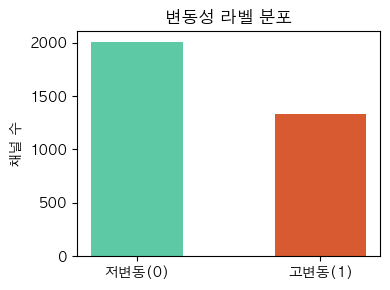

In [5]:
thr_log = feat_df["log_view_std"].median()
thr_mad = feat_df["mad_to_median"].median()

print(f"임계값 log_view_std  : {thr_log:.4f}")
print(f"임계값 mad_to_median : {thr_mad:.4f}")

feat_df["is_volatile"] = (
    (feat_df["log_view_std"]  > thr_log) &
    (feat_df["mad_to_median"] > thr_mad)
).astype(int)

print("\n=== 라벨 분포 ===")
vc = feat_df["is_volatile"].value_counts()
print(vc)
print(f"\n고변동 채널 비율: {feat_df['is_volatile'].mean():.1%}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["저변동(0)", "고변동(1)"], vc.values,
       color=["#5DCAA5", "#D85A30"], edgecolor="none", width=0.5)
ax.set_ylabel("채널 수")
ax.set_title("변동성 라벨 분포")
plt.tight_layout()
plt.show()

## 4. 피처-라벨 상관관계

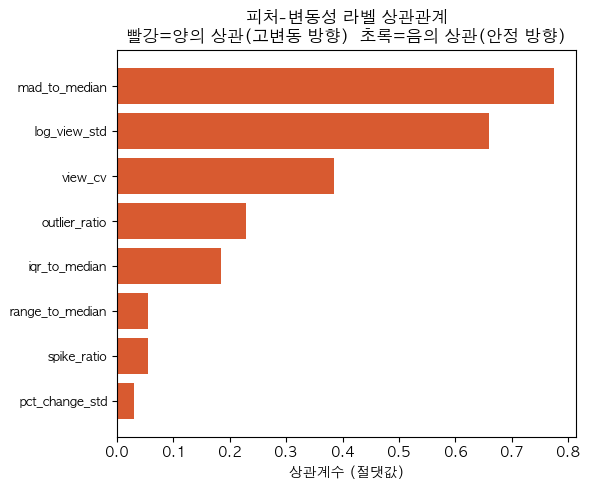

In [6]:
FEATURE_COLS = [
    "view_cv", "log_view_std", "mad_to_median", "iqr_to_median",
    "range_to_median", "outlier_ratio", "spike_ratio", "pct_change_std",
]

corr = feat_df[FEATURE_COLS + ["is_volatile"]].corr()["is_volatile"].drop("is_volatile")
corr_abs = corr.abs().sort_values(ascending=True)
colors = ["#D85A30" if corr[f] > 0 else "#5DCAA5" for f in corr_abs.index]

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(corr_abs.index, corr_abs.values, color=colors, edgecolor="none")
ax.set_xlabel("상관계수 (절댓값)")
ax.set_title("피처-변동성 라벨 상관관계\n빨강=양의 상관(고변동 방향)  초록=음의 상관(안정 방향)")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 5. 고변동 / 저변동 채널 조회수 추이 비교 (샘플)

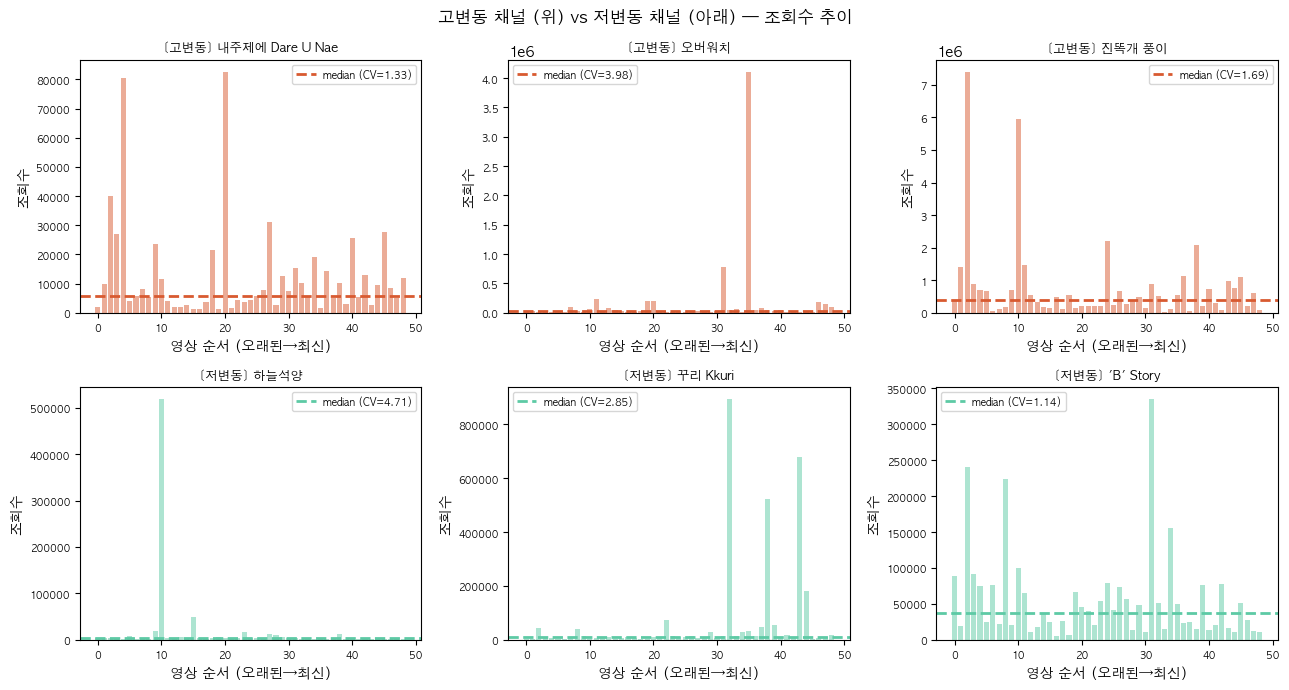

In [7]:
volatile_ids = feat_df[feat_df["is_volatile"] == 1]["channel_id"].tolist()[:3]
stable_ids   = feat_df[feat_df["is_volatile"] == 0]["channel_id"].tolist()[:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle("고변동 채널 (위) vs 저변동 채널 (아래) — 조회수 추이", fontsize=12)

for i, (cid, ax) in enumerate(zip(volatile_ids + stable_ids, axes.flatten())):
    g = long[long["channel_id"] == cid].sort_values("published_at").iloc[:-1]
    views = g["view_count"].fillna(0).to_numpy(dtype=float)
    x = np.arange(len(views))
    median_v = np.median(views)

    color = "#D85A30" if i < 3 else "#5DCAA5"
    label = "고변동" if i < 3 else "저변동"
    title = g["channel_title"].iloc[0][:15]
    cv    = np.std(views) / (np.mean(views) + 1e-9)

    ax.bar(x, views, color=color, alpha=0.5, edgecolor="none", width=0.8)
    ax.axhline(median_v, color=color, lw=2, linestyle="--", label=f"median (CV={cv:.2f})")
    ax.set_title(f"[{label}] {title}", fontsize=9)
    ax.set_xlabel("영상 순서 (오래된→최신)")
    ax.set_ylabel("조회수")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

## 6. 모델 정의

3개 모델의 **앙상블 평균**을 최종 변동성 확률로 사용합니다.  
XGBoost는 `CalibratedClassifierCV`로 확률 보정합니다.

In [8]:
X = feat_df[FEATURE_COLS].copy()
y = feat_df["is_volatile"].copy()

pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)

xgb_base = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 3,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

models = {
    "Logistic Regression": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", C=0.1,
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=5,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost (calibrated)": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", CalibratedClassifierCV(xgb_base, cv=3, method="isotonic")),
    ]),
}

print(f"피처 수 : {len(FEATURE_COLS)}")
print(f"샘플 수 : {len(X)}")
print(f"고변동 비율: {y.mean():.1%}")

피처 수 : 8
샘플 수 : 3333
고변동 비율: 39.8%


## 7. 교차검증

In [9]:
results = {}

for name, model in models.items():
    cv_res  = cross_validate(model, X, y, cv=CV,
                             scoring=["roc_auc","f1","recall","precision"])
    y_prob  = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    brier   = brier_score_loss(y, y_prob)

    results[name] = {
        "AUC-ROC"  : cv_res["test_roc_auc"].mean(),
        "F1"       : cv_res["test_f1"].mean(),
        "Recall"   : cv_res["test_recall"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Brier↓"   : round(brier, 4),
    }
    print(f"[{name}]  AUC={results[name]['AUC-ROC']:.3f}  F1={results[name]['F1']:.3f}  Brier={brier:.3f}")

res_df = pd.DataFrame(results).T.round(3)
print()
res_df

[Logistic Regression]  AUC=0.988  F1=0.928  Brier=0.044
[Random Forest]  AUC=1.000  F1=0.998  Brier=0.006
[XGBoost (calibrated)]  AUC=1.000  F1=0.997  Brier=0.002



,AUC-ROC,F1,Recall,Precision,Brier↓
Logistic Regression,0.988,0.928,0.949,0.908,0.044
Random Forest,1.000,0.998,0.997,0.998,0.006
XGBoost (calibrated),1.000,0.997,0.997,0.998,0.002


## 8. ROC 커브 & Calibration Curve

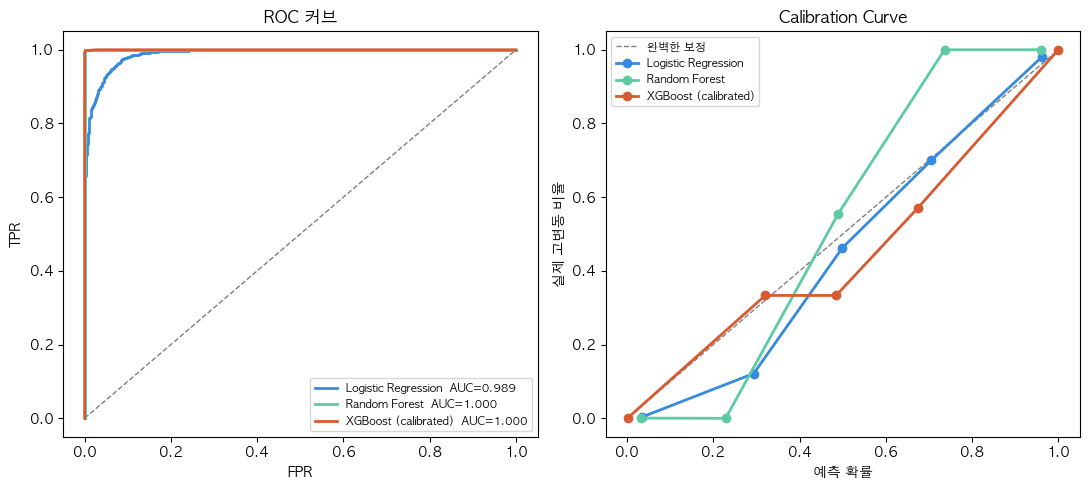

In [10]:
pal = {"Logistic Regression":"#378ADD",
       "Random Forest":"#5DCAA5",
       "XGBoost (calibrated)":"#D85A30"}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ROC
axes[0].plot([0,1],[0,1],"--", color="gray", lw=1)
for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name}  AUC={auc:.3f}", color=pal[name])
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC 커브"); axes[0].legend(fontsize=8)

# Calibration
axes[1].plot([0,1],[0,1],"--", color="gray", lw=1, label="완벽한 보정")
for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    frac, mean_p = calibration_curve(y, y_prob, n_bins=5, strategy="uniform")
    axes[1].plot(mean_p, frac, "o-", lw=2, label=name, color=pal[name])
axes[1].set_xlabel("예측 확률"); axes[1].set_ylabel("실제 고변동 비율")
axes[1].set_title("Calibration Curve"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. 채널별 변동성 확률 출력

전체 데이터 재학습 후 앙상블 평균을 `volatility_prob`으로 출력합니다.

In [11]:
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=FEATURE_COLS)

prob_dict = {}
for name, model in models.items():
    model.fit(X_imp, y)
    prob_dict[name] = model.predict_proba(X_imp)[:, 1]

probs = pd.DataFrame(prob_dict)
probs["volatility_prob"] = probs.mean(axis=1)
probs["channel_id"]      = feat_df["channel_id"].values
probs["title"]           = feat_df["channel_title"].values
probs["is_volatile"]     = y.values

output = probs[[
    "channel_id", "title", "is_volatile",
    "Logistic Regression", "Random Forest",
    "XGBoost (calibrated)", "volatility_prob"
]].sort_values("volatility_prob", ascending=False).reset_index(drop=True)

output.columns = [
    "channel_id", "title", "actual_label",
    "prob_lr", "prob_rf", "prob_xgb", "volatility_prob"
]
output = output.round(3)
print(f"변동성 확률 계산 완료: {len(output)}개 채널")
output

변동성 확률 계산 완료: 3333개 채널


,channel_id,title,actual_label,prob_lr,prob_rf,prob_xgb,volatility_prob
0,UC0bXUn25faBH-JzlUEHNh7g,웃긴협회,1,1.0,0.991,1.0,0.997
1,UCdUlCaxi7gx9Q-WDVDe30YA,배스킨라빈스,1,1.0,0.991,1.0,0.997
2,UCxXgIeE5hxWxHG6dz9Scg2w,RAIN's Official Channel,1,1.0,0.990,1.0,0.997
3,UCCn0jN1hH5m6hMOB51WyAKw,세호가중계,1,1.0,0.990,1.0,0.997
4,UC3pk0eDcZx_oYGCWNyJpjMQ,나돌_NADOL,1,1.0,0.990,1.0,0.997
...,...,...,...,...,...,...,...
3328,UCgm633UDZayRRxv4U5Y1DXA,1분트렌드 - 일트,0,0.0,0.000,0.0,0.000
3329,UCsgATy-l7XJ8AnWavH99WdQ,코이중대,0,0.0,0.000,0.0,0.000
3330,UC5QCza-qtDmujX_lzIs9SJw,세부부부,0,0.0,0.000,0.0,0.000
3331,UCJpAwvQaZyCI5spAz7tipGA,PAKA,0,0.0,0.000,0.0,0.000


## 10. 채널별 변동성 확률 시각화

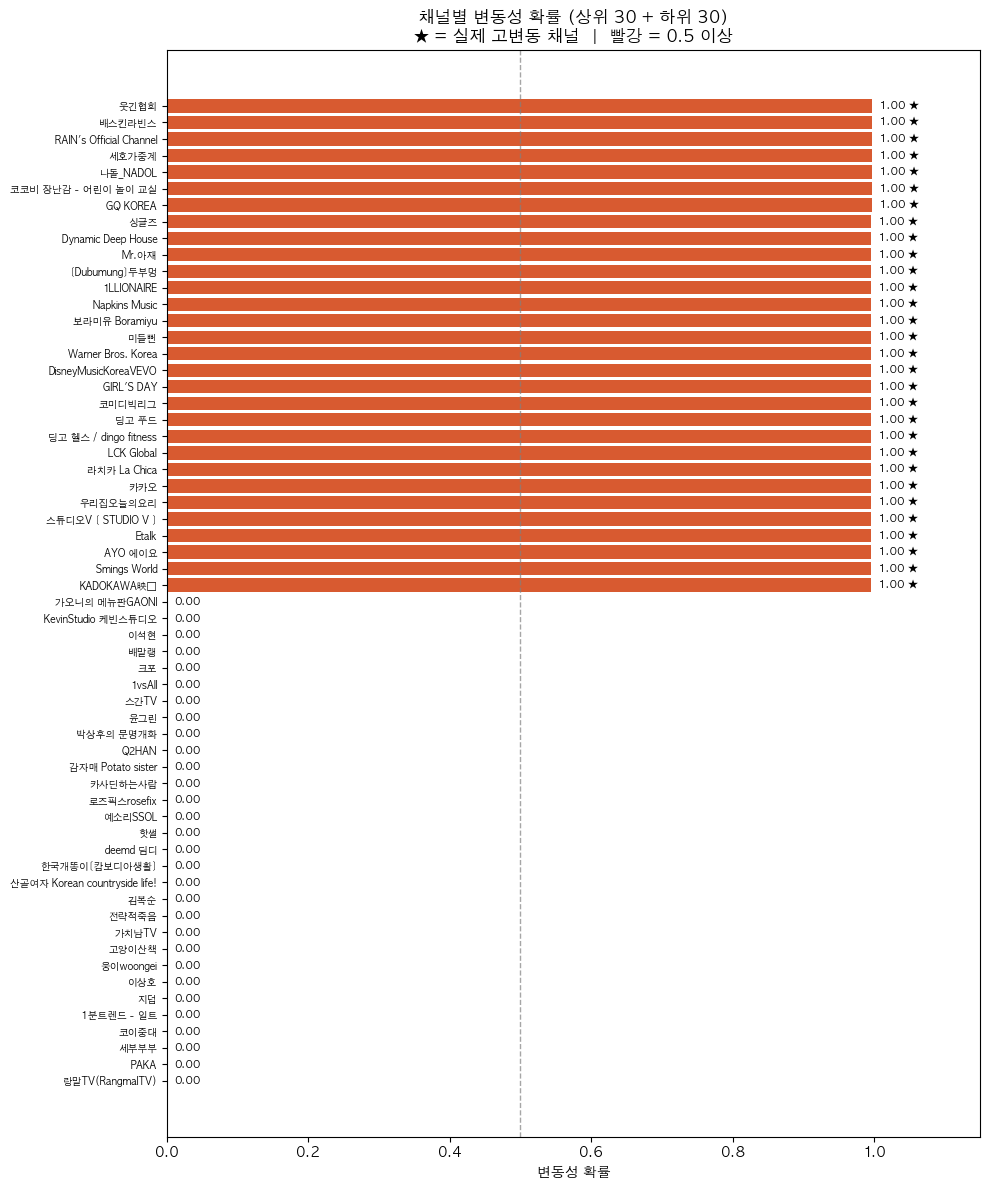

In [12]:
TOP_N = 30
vis = pd.concat([output.head(TOP_N), output.tail(TOP_N)]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors_bar = ["#D85A30" if v >= 0.5 else "#5DCAA5" for v in vis["volatility_prob"]]
ax.barh(vis["title"], vis["volatility_prob"],
        color=colors_bar, edgecolor="none")

for i, (prob, actual) in enumerate(zip(vis["volatility_prob"], vis["actual_label"])):
    marker = " ★" if actual == 1 else ""
    ax.text(prob + 0.01, i, f"{prob:.2f}{marker}", va="center", fontsize=8)

ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("변동성 확률")
ax.set_title(f"채널별 변동성 확률 (상위 {TOP_N} + 하위 {TOP_N})\n★ = 실제 고변동 채널  |  빨강 = 0.5 이상")
ax.set_xlim(0, 1.15)
ax.invert_yaxis()
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

## 11. 저장

In [14]:
output.to_csv("../../data/raw/view_volatility_output.csv", index=False, encoding="utf-8-sig")
print("저장 완료: view_volatility_output.csv")
print()
print("=== 변동성 확률 상위 10개 채널 ===")
print(output[["title","volatility_prob","actual_label"]].head(10).to_string(index=False))

저장 완료: view_volatility_output.csv

=== 변동성 확률 상위 10개 채널 ===
                  title  volatility_prob  actual_label
                   웃긴협회            0.997             1
                 배스킨라빈스            0.997             1
RAIN's Official Channel            0.997             1
                  세호가중계            0.997             1
               나돌_NADOL            0.997             1
    코코비 장난감 - 어린이 놀이 교실            0.997             1
               GQ KOREA            0.997             1
                    싱글즈            0.996             1
     Dynamic Deep House            0.996             1
                  Mr.아재            0.996             1
